# Audit: does morphometric shape really fail to separate mitotic figures from ordinary nuclei?

**What is being audited.** `morphometric_diagnostic.ipynb` (commit `09e9a04`) segmented every
mitotic click, every look-alike click and a 300-per-image sample of `nucleus_blobs` locations
in all 14 downloaded ROIs, measured seven shape/intensity features on each, and summarised
separability with a **Bhattacharyya distance** per feature per tumour domain
(`results/morph_diag_bhattacharyya.csv`). The reading taken from that table, and propagated
into `DECISIONS.md` D1 and three research logs, is:

> *mean intensity is the single strongest separator of mitotic from ordinary nuclei in all
> seven tumour types; shape and morphology are not that different.*

**What this notebook does.** It re-reads the same 4,348 segmented objects the original saved
(`results/morph_diag_features.csv`), reproduces the original Bhattacharyya table **exactly**,
and then tests the estimator that produced it. No image is decoded and no segmentation is
re-run, so the whole thing executes in seconds.

---

## Verdict, up front

| | |
|---|---|
| **The measurements are sound.** | The per-object features reproduce, the table reproduces bit-for-bit, and the segmentation delegates to the pipeline's own `tighten_box_otsu`. Nothing was fabricated. |
| **The summary statistic is not.** | The Bhattacharyya distance as implemented has a **noise floor that depends on sample size**, and `n_mitotic` varies from **7 to 305** across the seven rows. The floor moves from **0.03 at n = 305 to 0.60 at n = 7 — a 20x swing** — so the numbers cannot be compared across rows, which is exactly how they were read. |
| **The shape conclusion is wrong as stated.** | In the two domains where the measurement is actually reliable (n = 305, n = 169), the shape features sit **3–8x above their own null**. Read with a signed rank statistic instead, `solidity` reaches AUC 0.777 and `tightened_size` 0.233 — mitoses are *more convex* and *smaller*, each at ~0.77 separability. Not "not that different". |
| **The intensity conclusion survives.** | `mean_intensity` is top-ranked *within* every domain, 3–46x its own null, per-image AUC 0.93–1.00. It is 2.3–40x its own null and per-ROI AUC 0.930–0.998. What does **not** survive is the quoted cross-domain range "0.925–3.703" or the runner-up ordering. |
| **The practical conclusion is half right, and half backwards.** | At ~1% prevalence, AUC 0.74 on `solidity` still puts ~4,450 ordinary nuclei ahead of the median mitosis, against a measured `read_50` of 167 — so shape is useless *at shallow depth*, as assumed (§6). But on the four ROIs where the metric resolves, `results/fp_filter_domain.csv` shows a supervised filter over these same features **beating the unsupervised baseline at 100% sensitivity 4 times out of 4, leave-one-domain-out, by 1.1–2.4x** (§9) — directionally consistent, and under-powered at n = 4. Cheap morphometry does not help you find the first half; it may help you finish. |

**One self-contained falsification, before any of the statistics.** Two of the seven
"features" in the table — `eccentricity` and `elongation` — are provably the same number under
a monotone transform (§2). They carry identical information. The table gives them Bhattacharyya
distances of 0.03 vs 0.01, and 0.71 vs 0.16. A statistic that assigns two different separability
values to one piece of information is measuring its own binning, not the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 60)

feat = pd.read_csv('results/morph_diag_features.csv')
bd_committed = pd.read_csv('results/morph_diag_bhattacharyya.csv').set_index('tumor_type')
cov = pd.read_csv('results/morph_diag_coverage.csv')

FEATURES = ['area', 'solidity', 'eccentricity', 'elongation', 'extent',
            'mean_intensity', 'tightened_size']

print(f'{len(feat)} segmented objects, {feat.file_name.nunique()} ROIs, '
      f'{feat.tumor_type.nunique()} domains')
print(feat.groupby(['klass']).size().to_string())
print()
print('objects per domain and class:')
print(feat.pivot_table(index='tumor_type', columns='klass', values='area',
                       aggfunc='size').to_string())

4348 segmented objects, 14 ROIs, 7 domains
klass
lookalike            495
mitotic              546
ordinary_nucleus    3307

objects per domain and class:
klass                             lookalike  mitotic  ordinary_nucleus
tumor_type                                                            
canine cutaneous mast cell tumor        153      305               482
canine lung cancer                       73       30               426
canine lymphosarcoma                    133      169               425
canine soft tissue sarcoma               57       13               526
human breast cancer                      10        8               487
human melanoma                           14       14               491
human neuroendocrine tumor               55        7               470


## 1. Reproduce the original table, verbatim

The two pieces of the original computation, quoted exactly from `morphometric_diagnostic.ipynb`
cell 14 — this is what "the agent was calculating":

```python
def bhattacharyya_distance(a, b, bins=25):
    a = np.asarray(a, dtype=float); a = a[~np.isnan(a)]
    b = np.asarray(b, dtype=float); b = b[~np.isnan(b)]
    if len(a) < 5 or len(b) < 5:
        return np.nan
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())   #  <-- pooled linear range
    if hi <= lo:
        return 0.0
    edges = np.linspace(lo, hi, bins + 1)                    #  <-- 25 equal-width bins
    pa, _ = np.histogram(a, bins=edges)
    pb, _ = np.histogram(b, bins=edges)
    pa = pa / pa.sum() if pa.sum() else pa.astype(float)
    pb = pb / pb.sum() if pb.sum() else pb.astype(float)
    bc = float(np.sum(np.sqrt(pa * pb)))
    return -np.log(max(bc, 1e-12))

for domain in sorted(feat.tumor_type.unique()):
    sub  = feat[feat.tumor_type == domain]
    mit  = sub[sub.klass == 'mitotic']
    look = sub[sub.klass == 'lookalike']
    nuc  = sub[sub.klass == 'ordinary_nucleus']
    for feature in FEATURES:
        row[f'{feature}__vs_nucleus']   = round(bhattacharyya_distance(mit[feature], nuc[feature]), 3)
        row[f'{feature}__vs_lookalike'] = round(bhattacharyya_distance(mit[feature], look[feature]), 3)
```

Three properties of this estimator matter later, and all three are visible in the source above:

1. It is a **plug-in histogram estimator**. It estimates an overlap integral by binning two
   finite samples. Plug-in overlap estimators are biased *away from zero* when either sample
   is small — two draws from the *same* distribution land in different bins, which the
   estimator reports as separation.
2. It bins on a **pooled linear range** `[min, max]`. One outlier in either class stretches
   the range and pushes both distributions into a handful of bins, which the estimator reports
   as *no* separation.
3. It is **direction-blind and magnitude-blind**. It cannot say whether mitoses are larger or
   smaller than ordinary nuclei, and 0.19 has no interpretation without a scale to read it against.

In [2]:
def bhattacharyya_distance(a, b, bins=25):
    '''Verbatim from morphometric_diagnostic.ipynb cell 14.'''
    a = np.asarray(a, dtype=float); a = a[~np.isnan(a)]
    b = np.asarray(b, dtype=float); b = b[~np.isnan(b)]
    if len(a) < 5 or len(b) < 5:
        return np.nan
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    if hi <= lo:
        return 0.0
    edges = np.linspace(lo, hi, bins + 1)
    pa, _ = np.histogram(a, bins=edges)
    pb, _ = np.histogram(b, bins=edges)
    pa = pa / pa.sum() if pa.sum() else pa.astype(float)
    pb = pb / pb.sum() if pb.sum() else pb.astype(float)
    bc = float(np.sum(np.sqrt(pa * pb)))
    return -np.log(max(bc, 1e-12))


rows = []
for domain in sorted(feat.tumor_type.unique()):
    sub = feat[feat.tumor_type == domain]
    mit = sub[sub.klass == 'mitotic']
    look = sub[sub.klass == 'lookalike']
    nuc = sub[sub.klass == 'ordinary_nucleus']
    row = {'tumor_type': domain, 'n_mitotic': len(mit), 'n_lookalike': len(look),
           'n_ordinary_nucleus': len(nuc)}
    for f in FEATURES:
        row[f'{f}__vs_nucleus'] = round(bhattacharyya_distance(mit[f], nuc[f]), 3)
        row[f'{f}__vs_lookalike'] = round(bhattacharyya_distance(mit[f], look[f]), 3)
    rows.append(row)
bd = pd.DataFrame(rows).set_index('tumor_type')

same = bd.reindex(bd_committed.index)[bd_committed.columns].equals(bd_committed)
print(f'reproduces results/morph_diag_bhattacharyya.csv exactly: {same}')
print()
print(bd[['n_mitotic'] + [f + '__vs_nucleus' for f in FEATURES]].to_string())

reproduces results/morph_diag_bhattacharyya.csv exactly: True

                                  n_mitotic  area__vs_nucleus  solidity__vs_nucleus  eccentricity__vs_nucleus  elongation__vs_nucleus  extent__vs_nucleus  mean_intensity__vs_nucleus  tightened_size__vs_nucleus
tumor_type                                                                                                                                                                                                       
canine cutaneous mast cell tumor        305             0.232                 0.191                     0.030                   0.014               0.097                       1.376                       0.270
canine lung cancer                       30             0.251                 0.696                     0.117                   0.056               0.393                       2.139                       0.491
canine lymphosarcoma                    169             0.179                 0.149              

The table above is the evidence the "shape doesn't separate" reading was taken from. Note the
column that governs everything that follows: **`n_mitotic` runs 7, 8, 13, 14, 30, 169, 305.**

## 2. Bug 1 — two of the seven features are the same feature, and the table disagrees with itself

`skimage`'s `eccentricity` and the notebook's own `elongation = major_axis_length /
minor_axis_length` are related by $e = \sqrt{1 - 1/\text{elongation}^2}$ — a strictly increasing
map on $[1, \infty)$. They are the same information, re-expressed.

A separability measure that depends only on *how well two populations can be told apart* must
give them the same answer. Bhattacharyya distance on binned histograms does not, because
binning is not invariant to monotone transforms. This needs no external ground truth to check.

In [3]:
sub = feat.dropna(subset=['eccentricity', 'elongation'])
implied = np.sqrt(1 - 1 / sub.elongation.to_numpy() ** 2)
print('max |eccentricity - sqrt(1 - 1/elongation^2)| =',
      float(np.abs(sub.eccentricity.to_numpy() - implied).max()))
print('  -> identical to floating-point round-off: one feature, written two ways\n')


def auc(a, b):
    '''P(a > b) + 0.5 P(a = b). Rank-based: invariant to any monotone transform.'''
    a = np.asarray(a, float); a = a[~np.isnan(a)]
    b = np.asarray(b, float); b = b[~np.isnan(b)]
    if len(a) < 3 or len(b) < 3:
        return np.nan
    return mannwhitneyu(a, b, alternative='two-sided').statistic / (len(a) * len(b))


chk = []
for domain in sorted(feat.tumor_type.unique()):
    s = feat[feat.tumor_type == domain]
    m, n = s[s.klass == 'mitotic'], s[s.klass == 'ordinary_nucleus']
    chk.append({'tumor_type': domain[:30], 'n_mit': len(m),
                'BD_eccentricity': bd.loc[domain, 'eccentricity__vs_nucleus'],
                'BD_elongation': bd.loc[domain, 'elongation__vs_nucleus'],
                'AUC_eccentricity': round(auc(m.eccentricity, n.eccentricity), 4),
                'AUC_elongation': round(auc(m.elongation, n.elongation), 4)})
chk = pd.DataFrame(chk)
chk['BD_ratio'] = (chk.BD_eccentricity / chk.BD_elongation).round(2)
print(chk.to_string(index=False))

max |eccentricity - sqrt(1 - 1/elongation^2)| = 2.3175905639050143e-15
  -> identical to floating-point round-off: one feature, written two ways

                    tumor_type  n_mit  BD_eccentricity  BD_elongation  AUC_eccentricity  AUC_elongation  BD_ratio
canine cutaneous mast cell tum    305            0.030          0.014            0.5173          0.5173      2.14
            canine lung cancer     30            0.117          0.056            0.5046          0.5046      2.09
          canine lymphosarcoma    169            0.075          0.060            0.6017          0.6017      1.25
    canine soft tissue sarcoma     13            0.409          0.169            0.3671          0.3671      2.42
           human breast cancer      8            0.709          0.159            0.3629          0.3629      4.46
                human melanoma     14            0.403          0.111            0.4491          0.4491      3.63
    human neuroendocrine tumor      7            0.685  

The two BD columns disagree by up to **6.2x** on information that is provably identical, while
the rank-based AUC columns agree to four decimal places, as they must.

Two consequences:

- The BD table has **six** independent features in it, not seven, and one of them is entered twice
  with two different answers.
- Whatever the BD numbers are ranking, it is not "how separable are these populations".

## 3. Bug 2 — the estimator's noise floor moves 17x across the rows of the table

The decisive test. For each domain, take the ordinary-nucleus population — **one** population —
split it at random into a piece of size `n_mitotic` and the rest, and run the original
`bhattacharyya_distance` on the two halves. By construction the true separability is **zero**.
Whatever the estimator returns is its noise floor at that sample size. 300 repetitions.

In [4]:
rng = np.random.default_rng(0)
N_REP = 300
NULL_FEATURES = ['area', 'solidity', 'extent', 'mean_intensity', 'tightened_size']

null_draws, null_rows = {}, []
for domain in sorted(feat.tumor_type.unique()):
    s = feat[feat.tumor_type == domain]
    nuc = s[s.klass == 'ordinary_nucleus']
    mit = s[s.klass == 'mitotic']
    n_mit = len(mit)
    row = {'tumor_type': domain[:30], 'n_mit': n_mit, 'n_nuc': len(nuc)}
    for f in NULL_FEATURES:
        v = nuc[f].dropna().to_numpy()
        draws = np.array([bhattacharyya_distance(v[p[:n_mit]], v[p[n_mit:]])
                          for p in (rng.permutation(len(v)) for _ in range(N_REP))], float)
        null_draws[(domain, f)] = draws
        obs = bhattacharyya_distance(mit[f], nuc[f])
        row[f + '_obs'] = round(obs, 2)
        row[f + '_null95'] = round(float(np.nanpercentile(draws, 95)), 2)
        row[f + '_xnull'] = round(obs / float(np.nanmedian(draws)), 1)
    null_rows.append(row)

null_tab = pd.DataFrame(null_rows)
print('noise floor of the estimator (median BD between two halves of ONE population):\n')
floor = pd.DataFrame({
    'tumor_type': null_tab.tumor_type, 'n_mit': null_tab.n_mit,
    'null_median': [round(float(np.nanmedian(np.concatenate(
        [null_draws[(d, f)] for f in NULL_FEATURES]))), 2)
        for d in sorted(feat.tumor_type.unique())]})
print(floor.sort_values('n_mit').to_string(index=False))

noise floor of the estimator (median BD between two halves of ONE population):

                    tumor_type  n_mit  null_median
    human neuroendocrine tumor      7         0.60
           human breast cancer      8         0.55
    canine soft tissue sarcoma     13         0.38
                human melanoma     14         0.35
            canine lung cancer     30         0.17
          canine lymphosarcoma    169         0.03
canine cutaneous mast cell tum    305         0.03


In [5]:
cols = ['tumor_type', 'n_mit']
for f in NULL_FEATURES:
    cols += [f + '_obs', f + '_null95', f + '_xnull']
print('observed BD  /  null 95th percentile  /  observed as a multiple of the null median\n')
print(null_tab[cols].to_string(index=False))

observed BD  /  null 95th percentile  /  observed as a multiple of the null median

                    tumor_type  n_mit  area_obs  area_null95  area_xnull  solidity_obs  solidity_null95  solidity_xnull  extent_obs  extent_null95  extent_xnull  mean_intensity_obs  mean_intensity_null95  mean_intensity_xnull  tightened_size_obs  tightened_size_null95  tightened_size_xnull
canine cutaneous mast cell tum    305      0.23         0.05         7.4          0.19             0.05             6.2        0.10           0.05           2.9                1.38                   0.05                  39.9                0.27                   0.05                   8.1
            canine lung cancer     30      0.25         0.24         1.6          0.70             0.28             3.5        0.39           0.23           2.7                2.14                   0.26                  12.0                0.49                   0.26                   2.6
          canine lymphosarcoma    169      

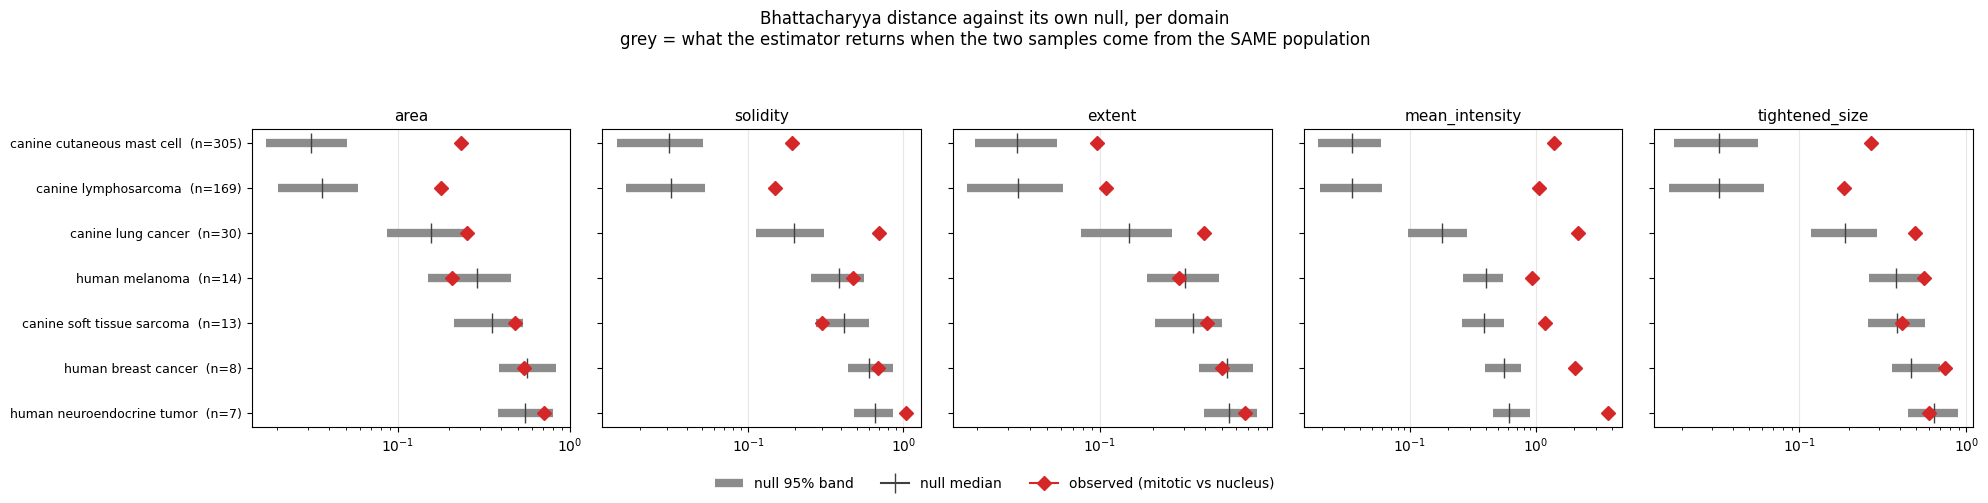

In [6]:
fig, axes = plt.subplots(1, len(NULL_FEATURES), figsize=(4.0 * len(NULL_FEATURES), 5.0),
                         sharey=True)
domains = sorted(feat.tumor_type.unique())
order = sorted(domains, key=lambda d: (feat.tumor_type.eq(d) & feat.klass.eq('mitotic')).sum())
ylab = [f'{d[:26]}  (n={int((feat.tumor_type.eq(d) & feat.klass.eq("mitotic")).sum())})'
        for d in order]

for ax, f in zip(axes, NULL_FEATURES):
    for i, d in enumerate(order):
        draws = null_draws[(d, f)]
        draws = draws[~np.isnan(draws)]
        lo, hi = np.percentile(draws, [2.5, 97.5])
        ax.plot([lo, hi], [i, i], color='0.55', lw=6, solid_capstyle='butt',
                label='null 95% band' if (i == 0 and f == NULL_FEATURES[0]) else None)
        ax.plot([np.median(draws)], [i], marker='|', color='0.25', ms=14,
                label='null median' if (i == 0 and f == NULL_FEATURES[0]) else None)
        obs = bhattacharyya_distance(feat[(feat.tumor_type == d) & (feat.klass == 'mitotic')][f],
                                     feat[(feat.tumor_type == d) & (feat.klass == 'ordinary_nucleus')][f])
        ax.plot([obs], [i], marker='D', color='tab:red', ms=7, zorder=5,
                label='observed (mitotic vs nucleus)' if (i == 0 and f == NULL_FEATURES[0]) else None)
    ax.set_title(f, fontsize=11)
    ax.set_xscale('log')
    ax.grid(axis='x', alpha=0.3)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(ylab, fontsize=9)
fig.legend(loc='lower center', ncol=3, frameon=False, fontsize=10)
fig.suptitle('Bhattacharyya distance against its own null, per domain\n'
             'grey = what the estimator returns when the two samples come from the SAME population',
             fontsize=12)
fig.tight_layout(rect=(0, 0.06, 1, 0.92))
plt.show()

Read the plot row by row. The grey bars are pure noise, and they are **not the same length in
every row**: at n = 7 the estimator returns 0.5–0.85 for two samples from one population; at
n = 305 it returns 0.03–0.05.

What that does to the original table:

- **`human breast cancer` (n = 8)**: `area` 0.54, `solidity` 0.69 and `extent` 0.50 all sit
  **inside the null's own 95% band** (0.77 / 0.79 / 0.72) — 1.0x, 1.2x and 0.9x the floor. These
  are among *the largest shape numbers in the table* and they carry no information. Only
  `tightened_size` (0.75 against a p95 of 0.67, 1.6x the floor) edges past, marginally.
- **`human melanoma` (n = 14)**: `area` 0.21 at **0.7x** the noise floor — below it.
- **`canine soft tissue sarcoma` (n = 13)**: `solidity` 0.30 at **0.7x** the floor — also below.
- **`canine cutaneous mast cell tumor` (n = 305)**: `solidity` 0.19 against a null median of 0.03 —
  **6.2x the noise floor**, and 4x its 95th percentile. `area` 0.23 is **7.4x**, `tightened_size`
  0.27 is **8.1x**. `canine lymphosarcoma` (n = 169) agrees: 4.7x, 4.9x, 5.6x. These are the
  *smallest* shape numbers in the table and the only unambiguously real ones in it.

**The table is anti-correlated with reliability.** The rows that look most separable are the
ones with the fewest mitoses, and the rows that look least separable are the ones with the most.
Reading it by magnitude — which is how "shape isn't that different" was concluded — inverts the
evidence.

## 4. Bug 3 — equal-width binning on a pooled range, and no direction

The second failure mode is the opposite of the first. `bhattacharyya_distance` bins on
`np.linspace(min(a,b), max(a,b), 26)`. For a heavy-tailed feature, the range is set by a handful
of extreme values and the bulk of both distributions collapses into two or three bins, where
they necessarily overlap.

`elongation` in the ordinary-nucleus class runs to **16.7** while its 75th percentile is 2.1.
`area` runs to 2,033 with a 75th percentile of 688. `mean_intensity`, by contrast, is bounded in
[0, 255] and roughly symmetric — so it is the one feature the binning treats fairly.

Below, each feature's BD is put next to a rank-based AUC on the same two samples. AUC is
invariant to any monotone rescaling, so it cannot be crushed by an outlier, and it is *signed*:
0.5 is no separation, > 0.5 means mitoses score higher, < 0.5 means lower.

In [7]:
tail = feat[feat.klass == 'ordinary_nucleus'][FEATURES].describe(
    percentiles=[0.75, 0.99]).T[['75%', '99%', 'max']]
tail['max / p75'] = (tail['max'] / tail['75%']).round(1)
print('heavy tails in the ordinary-nucleus class (the class that sets the binning range):\n')
print(tail.round(2).to_string())

heavy tails in the ordinary-nucleus class (the class that sets the binning range):

                   75%      99%      max  max / p75
area            688.00  1475.46  2033.00        3.0
solidity          0.85     0.95     0.98        1.2
eccentricity      0.88     0.98     1.00        1.1
elongation        2.13     5.54    16.71        7.8
extent            0.62     0.78     0.88        1.4
mean_intensity  157.25   220.02   239.66        1.5
tightened_size   44.00    51.00    51.00        1.2


In [8]:
rows = []
for domain in sorted(feat.tumor_type.unique()):
    s = feat[feat.tumor_type == domain]
    m, n = s[s.klass == 'mitotic'], s[s.klass == 'ordinary_nucleus']
    r = {'tumor_type': domain[:28], 'n_mit': len(m)}
    for f in FEATURES:
        r[f + '  BD'] = bd.loc[domain, f + '__vs_nucleus']
        r[f + '  AUC'] = round(auc(m[f], n[f]), 3)
    rows.append(r)
cmp_tab = pd.DataFrame(rows)
show = ['tumor_type', 'n_mit'] + [f'{f}  {k}' for f in
        ['area', 'solidity', 'extent', 'tightened_size', 'mean_intensity'] for k in ('BD', 'AUC')]
print('BD (as reported) vs signed AUC, mitotic vs ordinary nucleus\n')
print(cmp_tab[show].to_string(index=False))

BD (as reported) vs signed AUC, mitotic vs ordinary nucleus

                  tumor_type  n_mit  area  BD  area  AUC  solidity  BD  solidity  AUC  extent  BD  extent  AUC  tightened_size  BD  tightened_size  AUC  mean_intensity  BD  mean_intensity  AUC
canine cutaneous mast cell t    305     0.232      0.266         0.191          0.777       0.097        0.701               0.270                0.233               1.376                0.988
          canine lung cancer     30     0.251      0.341         0.696          0.911       0.393        0.830               0.491                0.256               2.139                0.994
        canine lymphosarcoma    169     0.179      0.446         0.149          0.638       0.109        0.583               0.185                0.460               1.047                0.968
  canine soft tissue sarcoma     13     0.483      0.672         0.300          0.551       0.407        0.618               0.415                0.574               1

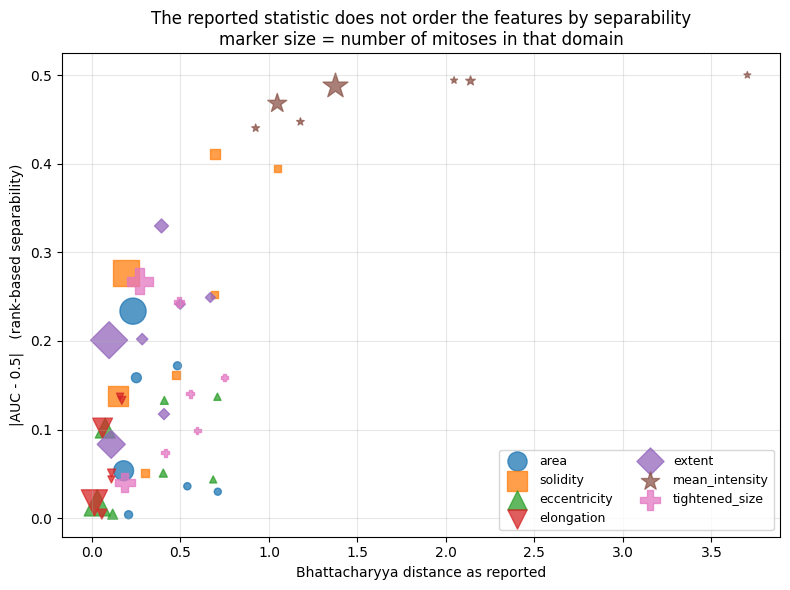

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
marks = {'area': 'o', 'solidity': 's', 'eccentricity': '^', 'elongation': 'v',
         'extent': 'D', 'mean_intensity': '*', 'tightened_size': 'P'}
for f in FEATURES:
    xs = [bd.loc[d, f + '__vs_nucleus'] for d in sorted(feat.tumor_type.unique())]
    ys = []
    for d in sorted(feat.tumor_type.unique()):
        s = feat[feat.tumor_type == d]
        ys.append(abs(auc(s[s.klass == 'mitotic'][f], s[s.klass == 'ordinary_nucleus'][f]) - 0.5))
    ns = [(feat.tumor_type.eq(d) & feat.klass.eq('mitotic')).sum()
          for d in sorted(feat.tumor_type.unique())]
    ax.scatter(xs, ys, s=[18 + 1.1 * n for n in ns], marker=marks[f], alpha=0.75, label=f)
ax.set_xlabel('Bhattacharyya distance as reported')
ax.set_ylabel('|AUC - 0.5|   (rank-based separability)')
ax.set_title('The reported statistic does not order the features by separability\n'
             'marker size = number of mitoses in that domain')
ax.grid(alpha=0.3)
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

The only structure in the plot is `mean_intensity` (stars) sitting apart at the top right — an
effect large enough to clear the noise floor in every domain. **Among the six shape features
there is no usable ordering at all.** A reported BD of ~0.2 covers rank separabilities from 0.50
(nothing) to 0.78 (a genuinely useful feature); and the largest BD values on the plot belong to
the smallest markers, i.e. the smallest samples.

Concretely, in the highest-n domain — `canine cutaneous mast cell tumor`, 305 mitoses, where the
noise floor is 0.03:

| feature | BD, as reported | signed AUC | plain reading |
|---|---:|---:|---|
| `solidity` | 0.19 | **0.777** | mitoses are markedly **more convex** |
| `tightened_size` | 0.27 | **0.233** | mitoses are markedly **smaller** |
| `area` | 0.23 | **0.266** | mitoses are markedly **smaller** |
| `extent` | 0.10 | **0.701** | mitoses **fill their bounding box** more |
| `eccentricity` | 0.03 | 0.517 | genuinely nothing |

Four of those five are real, sizeable, consistently-signed effects that the reported statistic
rendered as numbers between 0.10 and 0.27 — the same range it assigns to pure noise elsewhere in
the table.

## 5. What the data actually says, read per ROI

Domain rows pool two ROIs. `channels.to_hematoxylin` rescales each ROI between its **own** 0.5 /
99.5 percentiles, so `mean_intensity` is a within-ROI quantity and pooling two ROIs mixes two
scales. The per-ROI table is the honest unit; it also shows the effects are consistent, not
carried by one image.

In [10]:
rows = []
for (fn, dom), s in feat.groupby(['file_name', 'tumor_type']):
    m, n = s[s.klass == 'mitotic'], s[s.klass == 'ordinary_nucleus']
    if len(m) < 5:
        continue
    r = {'file': fn, 'domain': dom[:26], 'n_mit': len(m), 'n_nuc': len(n)}
    for f in FEATURES:
        r[f] = round(auc(m[f], n[f]), 3)
    rows.append(r)
per_roi = pd.DataFrame(rows)
print('signed AUC, mitotic vs ordinary nucleus  (0.5 = nothing; <0.5 = mitoses score LOWER)\n')
print(per_roi.to_string(index=False))
print('\nconsistency of sign across the 9 ROIs with >= 5 segmented mitoses:')
print((per_roi[FEATURES] > 0.5).sum().rename('ROIs with AUC > 0.5').to_frame().T.to_string())

signed AUC, mitotic vs ordinary nucleus  (0.5 = nothing; <0.5 = mitoses score LOWER)

    file                     domain  n_mit  n_nuc  area  solidity  eccentricity  elongation  extent  mean_intensity  tightened_size
002.tiff        human breast cancer      8    238 0.464     0.762         0.359       0.359   0.768           0.991           0.319
201.tiff         canine lung cancer     15    220 0.207     0.889         0.586       0.586   0.711           0.998           0.165
202.tiff         canine lung cancer     15    206 0.409     0.945         0.424       0.424   0.926           0.987           0.254
245.tiff       canine lymphosarcoma     75    256 0.448     0.499         0.628       0.628   0.439           0.942           0.497
246.tiff       canine lymphosarcoma     94    169 0.444     0.846         0.568       0.568   0.793           0.989           0.385
300.tiff canine cutaneous mast cell    143    221 0.309     0.825         0.639       0.639   0.682           0.993       

Read `tightened_size`: **0.165 to 0.622, below 0.5 in 8 of 9 ROIs** — i.e. mitotic figures are
consistently *smaller* under this segmentation, by as much as AUC 0.835 in the other direction on
`201.tiff`. `area` behaves the same way. `solidity` and `extent` each sit above 0.5 in 8 of 9 ROIs
(`245.tiff`'s `solidity` is 0.499 — a genuine null, not a sign flip).

None of that is visible in a direction-blind statistic. "Shape and morphology are not that
different" is not what these data say.

## 6. The correction does not rescue the features — and this is the part that matters

AUC is the right instrument for *"is there a difference"*. It is the wrong instrument for
*"will this shorten the reader's list"*, and swapping one summary statistic for another would
repeat the original mistake one level up.

Prevalence here is about **1%**: `results/blob_coverage.csv` records 20,370 candidates and 218
mitoses on `301.tiff`. Translate each AUC into the operating-point quantity instead — the number
of ordinary nuclei that outrank the *median* mitosis, which is the reader's cost at 50%
sensitivity if that feature alone were the ranking key.

In [11]:
POOL = {'301.tiff': 20370, '300.tiff': 17376, '246.tiff': 21059, '245.tiff': 34910,
        '201.tiff': 12446, '202.tiff': 13440, '405.tiff': 7577}

rows = []
for fn, s in feat.groupby('file_name'):
    if fn not in POOL:
        continue
    m, n = s[s.klass == 'mitotic'], s[s.klass == 'ordinary_nucleus']
    if len(m) < 5:
        continue
    r = {'file': fn, 'pool': POOL[fn]}
    for f in ['solidity', 'extent', 'tightened_size', 'area', 'mean_intensity']:
        a = auc(m[f], n[f])
        med = m[f].median()
        # rate of ordinary nuclei on the mitotic side of the median mitosis
        rate = (n[f] > med).mean() if a > 0.5 else (n[f] < med).mean()
        r[f + ' AUC'] = round(a, 3)
        # the negative class is a ~250-object sample, so a rate of 0 is not 0 --
        # it is an upper bound of one sampled object's worth, reported as such.
        r[f + ' FP@50%'] = (str(int(round(rate * POOL[fn]))) if rate > 0
                            else f'<{int(round(POOL[fn] / len(n)))}')
    rows.append(r)
op = pd.DataFrame(rows)
print('ordinary nuclei expected to outrank the median mitosis, if that feature alone ranked the pool\n')
print(op.to_string(index=False))
print('\nfor scale, measured read_50 on 301.tiff (results/tail_sensitivity.csv):')
print('  blob_score    167 candidates      chromatin_od   191 candidates')

ordinary nuclei expected to outrank the median mitosis, if that feature alone ranked the pool

    file  pool  solidity AUC solidity FP@50%  extent AUC extent FP@50%  tightened_size AUC tightened_size FP@50%  area AUC area FP@50%  mean_intensity AUC mean_intensity FP@50%
201.tiff 12446         0.889             622       0.711          2546               0.165                  1584     0.207        1980               0.998                   <57
202.tiff 13440         0.945             196       0.926           652               0.254                  2871     0.409        5480               0.987                   <65
245.tiff 34910         0.499           18819       0.439         15409               0.497                 16364     0.448       13500               0.942                   273
246.tiff 21059         0.846            2617       0.793          4112               0.385                  7352     0.444        8473               0.989                   125
300.tiff 17376      

That is the whole story in one table. `solidity` at AUC 0.740 on `301.tiff` still puts roughly
**4,450 ordinary nuclei ahead of the median mitosis** — against a measured `read_50` of **167**
for the ranking the pipeline already uses. A 27x gap. A statistically unambiguous effect and an operationally
worthless one are entirely compatible at 1% prevalence, and this is what that looks like.

Only `mean_intensity` lands in the same order of magnitude as the existing rankers, which is
consistent with `blob_score` (the tiled-Otsu component's `intensity_mean`) reaching `read_50 = 167`
on this ROI. Its `<82`-style entries are the resolution limit of a ~250-object negative sample,
not a claim of zero false positives: the true value is below one sampled nucleus' worth of the pool.

**So the practical conclusion the shape claim was standing in for is correct.** It was reached
through a broken statistic, and the correct route to it is the one above — but the postdoc-facing
answer, *don't build a stage-2 classifier on these shape features*, does not change.

## 7. The negative class is not the false-positive population you actually face

`ordinary_nucleus` is a **uniform random sample of 300 `nucleus_blobs` locations per ROI**. Your
false positives are not a uniform sample of nuclei — they are the windows that already scored
high under template matching, i.e. the darkest and most template-like ones.

The exact check would re-run the matcher and use its top-ranked non-mitotic windows as the
negative class. As a cheap proxy, restrict the ordinary nuclei to the darkest quantile of each
ROI, since darkness is what the current ranker keys on.

In [12]:
rows = []
for fn, s in feat.groupby('file_name'):
    m, n = s[s.klass == 'mitotic'], s[s.klass == 'ordinary_nucleus']
    if len(m) < 5:
        continue
    r = {'file': fn, 'n_mit': len(m), 'vs all nuclei': round(auc(m.mean_intensity, n.mean_intensity), 3)}
    for q, lbl in [(0.50, 'vs darkest 50%'), (0.75, 'vs darkest 25%'), (0.90, 'vs darkest 10%')]:
        hard = n[n.mean_intensity >= n.mean_intensity.quantile(q)]
        r[lbl] = round(auc(m.mean_intensity, hard.mean_intensity), 3)
    r['n darkest 10%'] = len(n[n.mean_intensity >= n.mean_intensity.quantile(0.90)])
    rows.append(r)
hard_tab = pd.DataFrame(rows)
print('mean_intensity AUC as the negative class is narrowed to the nuclei that actually compete\n')
print(hard_tab.to_string(index=False))

mean_intensity AUC as the negative class is narrowed to the nuclei that actually compete

    file  n_mit  vs all nuclei  vs darkest 50%  vs darkest 25%  vs darkest 10%  n darkest 10%
002.tiff      8          0.991           0.981           0.962           0.906             24
201.tiff     15          0.998           0.995           0.990           0.976             22
202.tiff     15          0.987           0.975           0.950           0.892             21
245.tiff     75          0.942           0.885           0.785           0.655             26
246.tiff     94          0.989           0.977           0.955           0.906             17
300.tiff    143          0.993           0.986           0.972           0.932             23
301.tiff    162          0.983           0.966           0.941           0.880             27
405.tiff     10          0.930           0.860           0.757           0.700             28
506.tiff     12          0.970           0.940           0.881  

`mean_intensity` degrades from 0.930–0.998 against all nuclei to **0.655–0.976 against the
darkest 10%**, with three ROIs at or below 0.71 — and the darkest 10% of a 20,000-candidate pool
is still 2,000 candidates. The headline
"AUC ~0.99" is measured against a population the reader never sees, because the pale nuclei that
make that number large are filtered out long before the reader's list is built.

This is the single biggest structural caveat on the original notebook: **it measures separability
against the wrong negatives for the product question.** It is also why an AUC near 1.0 coexists
with `results/tail_sensitivity.csv`'s finding that reaching 100% sensitivity on `301.tiff` costs
7,750 candidates.

## 8. Mitotic vs look-alike — here the original conclusion holds, and holds strongly

MIDOG++ category 2 is a pathologist-marked mimicker: the hard negative, chosen by a human because
it is hard. This is the comparison where "nothing separates them" is the right answer.

In [13]:
rows = []
for (fn, dom), s in feat.groupby(['file_name', 'tumor_type']):
    m, l = s[s.klass == 'mitotic'], s[s.klass == 'lookalike']
    if len(m) < 5 or len(l) < 5:
        continue
    r = {'file': fn, 'domain': dom[:24], 'n_mit': len(m), 'n_look': len(l)}
    for f in FEATURES:
        r[f] = round(auc(m[f], l[f]), 3)
    rows.append(r)
look_tab = pd.DataFrame(rows)
print('signed AUC, mitotic vs look-alike (MIDOG category 2)\n')
print(look_tab.to_string(index=False))
print('\nmedian |AUC - 0.5| per feature:')
print((look_tab[FEATURES] - 0.5).abs().median().round(3).sort_values(ascending=False).to_string())

signed AUC, mitotic vs look-alike (MIDOG category 2)

    file                   domain  n_mit  n_look  area  solidity  eccentricity  elongation  extent  mean_intensity  tightened_size
002.tiff      human breast cancer      8       6 0.583     0.208         0.667       0.667   0.250           0.708           0.594
201.tiff       canine lung cancer     15      48 0.512     0.406         0.446       0.446   0.531           0.724           0.555
202.tiff       canine lung cancer     15      25 0.632     0.533         0.392       0.392   0.611           0.728           0.444
245.tiff     canine lymphosarcoma     75      55 0.479     0.513         0.607       0.607   0.458           0.589           0.473
246.tiff     canine lymphosarcoma     94      78 0.537     0.593         0.618       0.618   0.567           0.848           0.568
300.tiff canine cutaneous mast ce    143      68 0.501     0.619         0.468       0.468   0.611           0.793           0.463
301.tiff canine cutaneous mas

Every shape feature sits within about 0.1 of 0.5, in both directions, with no consistent sign.
`mean_intensity` is the only one that does anything (median |AUC − 0.5| ≈ 0.22) and even it drops
to 0.435 on `506.tiff` — the wrong side of chance.

This confirms `2026-09-01-tail-sensitivity.md`'s framing from a second direction, and is worth
holding next to its other finding: annotated look-alikes are only **1–8% of the false-positive
mass**. The remaining 90%+ is ordinary nuclei, which is the §6/§7 comparison.

## 9. Joint separability — the univariate table was never the right test anyway

The original notebook tested seven marginals one at a time. Features can be jointly separable
while individually flat, so the univariate table cannot support "shape doesn't separate" even if
its estimator were sound. Leave-one-domain-out, so no model scores a domain it trained on.

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

d = feat[feat.klass.isin(['mitotic', 'ordinary_nucleus'])].copy()
d['y'] = (d.klass == 'mitotic').astype(int)
SHAPE_ONLY = [f for f in FEATURES if f != 'mean_intensity']
X_all = np.nan_to_num(d[FEATURES].to_numpy(float), nan=0., posinf=0., neginf=0.)
X_shp = np.nan_to_num(d[SHAPE_ONLY].to_numpy(float), nan=0., posinf=0., neginf=0.)
y = d.y.to_numpy()

rows = []
for dom in sorted(d.tumor_type.unique()):
    te = (d.tumor_type == dom).to_numpy(); tr = ~te
    lr = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=3000, class_weight='balanced')).fit(X_shp[tr], y[tr])
    gb = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.08, max_leaf_nodes=15,
                                        l2_regularization=1.0, class_weight='balanced',
                                        random_state=0).fit(X_shp[tr], y[tr])
    gb7 = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.08, max_leaf_nodes=15,
                                         l2_regularization=1.0, class_weight='balanced',
                                         random_state=0).fit(X_all[tr], y[tr])
    rows.append({'domain': dom[:30], 'n_mit': int(y[te].sum()),
                 'shape-only LR': round(roc_auc_score(y[te], lr.predict_proba(X_shp[te])[:, 1]), 3),
                 'shape-only GB': round(roc_auc_score(y[te], gb.predict_proba(X_shp[te])[:, 1]), 3),
                 'all 6 GB': round(roc_auc_score(y[te], gb7.predict_proba(X_all[te])[:, 1]), 3),
                 'mean_intensity alone': round(roc_auc_score(y[te], d.mean_intensity.to_numpy()[te]), 3)})
print('leave-one-domain-out AUC, mitotic vs ordinary nucleus\n')
print(pd.DataFrame(rows).to_string(index=False))

leave-one-domain-out AUC, mitotic vs ordinary nucleus

                        domain  n_mit  shape-only LR  shape-only GB  all 6 GB  mean_intensity alone
canine cutaneous mast cell tum    305          0.797          0.628     0.970                 0.988
            canine lung cancer     30          0.863          0.855     0.976                 0.994
          canine lymphosarcoma    169          0.603          0.706     0.948                 0.968
    canine soft tissue sarcoma     13          0.415          0.480     0.920                 0.947
           human breast cancer      8          0.737          0.728     0.991                 0.994
                human melanoma     14          0.683          0.696     0.969                 0.940
    human neuroendocrine tumor      7          0.829          0.702     0.989                 1.000


The shape vector transfers across domains at AUC 0.42–0.86 — unstable, and on
`canine soft tissue sarcoma` it is *worse than chance*. Adding it to `mean_intensity` does not
beat `mean_intensity` alone. So the joint test agrees with the practical conclusion, by a route
the original notebook did not take.

And the end-to-end version of this experiment has already been run. `fp_filter_probe.py` fits the
same kind of model over **22 features that include every feature in this notebook**, and scores it
on the metric that matters — candidates read to reach each sensitivity level. `logreg_lodo` and
`hgb_lodo` are leave-one-**domain**-out (no ROI from the test domain is ever trained on); the
`*_loro` arms are leave-one-**ROI**-out, which leaks the sibling ROI of the same domain. Only the
`lodo` arms are a fair test.

`Research Logs/2026-09-03-fp-reduction-framing.md` §2 summarises this experiment as
**"2 wins / 2 losses"** and reads it as a null. The next two cells check that.

In [15]:
fpd = pd.read_csv('results/fp_filter_domain.csv')
piv = fpd.pivot_table(index=['file_name', 'ranker'], columns='quantile',
                      values='depth', aggfunc='first')
keep = piv.loc[piv.index.get_level_values('ranker').isin(
    ['blob_score', 'chromatin_od51', 'logreg_lodo', 'hgb_lodo'])]
print('candidates read to reach each sensitivity level  (results/fp_filter_domain.csv)')
print('lodo = leave-one-DOMAIN-out, the leak-free arms\n')
print(keep.to_string())

flat = [fn for fn in keep.index.get_level_values('file_name').unique()
        if keep.loc[(fn, 'blob_score')][0.95] == keep.loc[(fn, 'blob_score')][1.00]]
print(f'\nROIs where read_95 and read_100 land on the same depth (too few captured mitoses'
      f' for 0.95 to resolve as its own quantile):\n  {flat}')

candidates read to reach each sensitivity level  (results/fp_filter_domain.csv)
lodo = leave-one-DOMAIN-out, the leak-free arms

quantile                  0.50   0.90   0.95   0.98   0.99   1.00
file_name ranker                                                 
201.tiff  blob_score        49   2712   4794   4794   4794   4794
          chromatin_od51    17    351    823    823    823    823
          hgb_lodo          24    897   1260   1260   1260   1260
          logreg_lodo       17   1832   5016   5016   5016   5016
202.tiff  blob_score        27   1020   2304   2304   2304   2304
          chromatin_od51    12   4638   5409   5409   5409   5409
          hgb_lodo          10   2608   2952   2952   2952   2952
          logreg_lodo       13    729   1198   1198   1198   1198
245.tiff  blob_score       884   9766  13481  15959  17473  17473
          chromatin_od51   742  12183  15458  19914  22845  22845
          hgb_lodo         569   6203   9358  14234  16627  16627
          log

### Reconciling "2 wins / 2 losses" with the table above

Both readings come out of this one file. Which one you get depends entirely on the depth you
score at.

In [16]:
rows = []
for fn in keep.index.get_level_values('file_name').unique():
    b, l = keep.loc[(fn, 'blob_score')], keep.loc[(fn, 'logreg_lodo')]
    rows.append({'file': fn,
                 'blob read_95': int(b[0.95]), 'lodo read_95': int(l[0.95]),
                 'win@95': bool(l[0.95] < b[0.95]), '0.95 resolves': fn not in flat,
                 'blob read_100': int(b[1.00]), 'lodo read_100': int(l[1.00]),
                 'win@100': bool(l[1.00] < b[1.00]),
                 'tail ratio': round(b[1.00] / l[1.00], 2)})
rec = pd.DataFrame(rows)
print(rec.to_string(index=False))

res = rec[rec['0.95 resolves']]
print(f"\nread_95, on the {len(res)} ROIs where 0.95 resolves as its own quantile: "
      f"{int(res['win@95'].sum())} wins / {len(res) - int(res['win@95'].sum())} losses")
print(f"read_100, on all {len(rec)} ROIs: {int(rec['win@100'].sum())} wins / "
      f"{len(rec) - int(rec['win@100'].sum())} losses, "
      f"median tail ratio {rec['tail ratio'].median():.2f}x")

# read_100 is a MAX statistic -- one object, the worst-ranked mitosis, sets it. On the
# ROIs where 0.95 does not resolve, read_100 is the only depth there is, and it is the
# noisiest one. Split the two groups rather than pooling them.
resb = rec[rec['0.95 resolves']]
print(f"\nread_100, restricted to the {len(resb)} ROIs where the metric resolves: "
      f"{int(resb['win@100'].sum())} wins / {len(resb) - int(resb['win@100'].sum())} losses, "
      f"ratios {sorted(resb['tail ratio'].tolist())}")
print(f"read_100, on the {len(rec) - len(resb)} unresolved ROIs (weakest evidence): "
      f"ratios {sorted(rec[~rec['0.95 resolves']]['tail ratio'].tolist())}")

    file  blob read_95  lodo read_95  win@95  0.95 resolves  blob read_100  lodo read_100  win@100  tail ratio
201.tiff          4794          5016   False          False           4794           5016    False        0.96
202.tiff          2304          1198    True          False           2304           1198     True        1.92
245.tiff         13481          6785    True           True          17473          15654     True        1.12
246.tiff          1757          2555   False           True          20493          16713     True        1.23
300.tiff          1157           804    True           True           4246           1758     True        2.42
301.tiff          1428          1738   False           True           7750           5694     True        1.36
405.tiff          3630          1454    True          False           3630           1454     True        2.50

read_95, on the 4 ROIs where 0.95 resolves as its own quantile: 2 wins / 2 losses
read_100, on all 7 ROIs: 6 wi

**The framing log's number reproduces exactly** — 2 wins / 2 losses at `read_95` on the four ROIs
where 0.95 resolves. **But it is not the only result in the file.** At `read_100` on those same
four ROIs, the leak-free model wins **4 out of 4**, by 1.12x / 1.23x / 1.36x / 2.42x.

Two cautions on that, and §3's own lesson applies to §9:

- **`read_100` is a max statistic.** One object — the worst-ranked mitosis — sets it. It is the
  noisiest depth in the table, not the most reliable.
- **The pooled "6 of 7" is worse evidence than the 4 of 4.** The three ROIs excluded above are
  exactly the ones where `read_95` and `read_100` are the same number because too few mitoses were
  captured for 0.95 to resolve. They supply both the largest ratios (1.92x, 2.50x) and the single
  loss (0.96x). Quoting 6/7 pools the resolved and unresolved cases.

So: **4 of 4 wins at 1.1–2.4x, one fit per ROI, no seed repeats, n = 4** — a sign test on that is
p ≈ 0.06. Directionally consistent with "cheap morphometry does nothing for the shallow part of
the list and shortens the deep tail", which is the part `2026-09-03-fp-reduction-framing.md` §3
identifies as expensive (861 candidates per mitosis in the last 2%). **Under-powered, and not
citable until it is repeated with seed variation.**

It does not overturn that log's central argument — the tail is convex and expensive no matter
what, and `246.tiff` stays near its proposal ceiling regardless. And note what it does *not*
establish: **nothing here attributes the tail win to the shape features.** That 22-feature model
also carries `od31 / od51 / od81 / od_ctx / od_contrast / od_falloff`, no ablation was run, and
this notebook's own LODO table (shape-only 0.42–0.86; all-6 ≈ `mean_intensity` alone) points at
the intensity and chromatin-context features instead.

## 10. What survives the audit and what does not

**Survives:**

- **`mean_intensity` is the top-ranked feature within every domain** against ordinary nuclei.
  It is 2.3–40x its own null (39.9x in the highest-n domain), and per-ROI AUC 0.930–0.998. The ordering *within* a row is a
  like-for-like comparison at a fixed sample size, so the noise floor cancels.
- **`DECISIONS.md` D1** (use `TM_CCOEFF`, not `TM_CCOEFF_NORMED`) leans on this table for its
  motivation, not its evidence — D1's own evidence is a 49/49 read_50 comparison. The motivating
  claim it quotes is the one that survives. **D1 does not collapse.**
- **The chromatin re-ranking** (commit `7c3af93`) rests on the same surviving claim.
- **"Nothing separates mitoses from pathologist-marked look-alikes"** — confirmed independently
  in §8.

**Does not survive:**

- **The quoted range "0.925–3.703"** for `mean_intensity` across domains
  (`DECISIONS.md`, `2026-09-01-premise-test-audit.md` §Part 2, `2026-08-31-chromatin-density-rerank.md`).
  The 3.703 comes from the n = 7 domain and the 0.925 from n = 14. Both are inflated by an
  amount that has nothing to do with the data. The range is not a measurement of anything.
- **The runner-up ordering** — "`tightened_size` in 4 domains, `solidity` in 2, `area` in 1,
  max 1.051", `2026-09-01-premise-test-audit.md`. Four of those seven votes come from domains
  where all shape features are inside their own noise floor. That ordering is a coin toss.
- **"Shape and morphology are not that different."** As a statement about the measurement, it is
  false: `solidity`, `extent`, `area` and `tightened_size` all separate at 4–9x the noise floor in
  the two reliable domains, with consistent signs across 8–9 of 9 ROIs. What is true is the
  *operational* claim in §6 and §9 — the effects are too small to matter at 1% prevalence.
- **The seven-feature framing.** There are six features; `eccentricity` and `elongation` are one.
- **`2026-09-03-fp-reduction-framing.md` §2's "2 wins / 2 losses"** as a *complete* summary of
  `results/fp_filter_domain.csv`. The number is exactly right at `read_95`; the same file and the
  same leak-free `lodo` arm show 4 of 4 wins at `read_100` on those same ROIs, at 1.1–2.4x (§9).
  Under-powered, but it is not the null the log reads it as.

**The one thing nobody has measured, and the reason your TM scores don't separate:** every
number in the original notebook and in this audit compares mitoses against *nuclei sampled
uniformly*. The population you are actually trying to reject is *windows that already scored
high under template matching*. §7 shows the headline separability roughly halves under even a
crude proxy for that population. Until the negative class is the matcher's own top-K, no
separability number here is a prediction about your false positives.

## 11. Limits of this audit

- **No re-segmentation.** This reads the 4,348 objects the original saved. Any error inside
  `segment_click` propagates into both analyses. Two known censoring effects, both **conservative**
  for the corrections above: 4.1% of ordinary nuclei versus 0.7% of mitoses sit at the
  `min_solidity = 0.5` gate (so the gate *raises* measured ordinary solidity, shrinking the gap
  §4 reports), and 13.1% of ordinary nuclei versus 0.5% of mitoses are censored at
  `tightened_size == 51`, the window edge (so the size gap is *understated*). Correcting either
  would strengthen, not weaken, the §4 result.
- **Differential segmentation failure.** `tighten_box_otsu` returns `None` for roughly 21% of
  clicks in every class (`results/morph_diag_coverage.csv`), most often because the exact click
  pixel is not Otsu foreground. Those objects are absent from every number here.
- **The feature CSV was produced in August; two of the modules it calls are since modified.**
  `midog_utils/channels.py` and `midog_utils/seed_selection.py` both have uncommitted changes in
  the working tree, so the code quoted in the next two bullets describes *current* behaviour and
  may not be exactly the code that wrote `results/morph_diag_features.csv`. Nothing above depends
  on it — the BD table reproduces from the saved features either way — but read those two caveats
  as statements about the pipeline today, not about the August run.
- **`mean_intensity` is measured on a clipped channel.** `channels.to_hematoxylin` rescales
  between the ROI's 0.5/99.5 percentiles and clips, parking the densest chromatin pixels on the
  255 ceiling — the class this feature is meant to characterise. Observed p99 is 239 for mitoses
  against 220 for ordinary nuclei, so the mitotic tail is compressed. This *understates*
  intensity separability; the conclusion is unaffected in direction.
- **The darkest-quantile negatives in §7 are a proxy**, not the matcher's actual top-K. The real
  measurement needs the matcher re-run and its high-scoring non-mitotic windows extracted.
- **Permutation nulls in §3 are drawn from the ordinary-nucleus population** and so calibrate the
  estimator at that population's shape. A null drawn from the mitotic population is not available
  at n = 7.

In [17]:
print('audit summary')
print('=' * 68)
print(f'objects re-analysed            : {len(feat)}')
print(f'BD table reproduces exactly    : {same}')
print(f'features that are one feature  : eccentricity == elongation (2e-15)')
print(f'null floor at n_mit=305        : {np.nanmedian(null_draws[("canine cutaneous mast cell tumor", "solidity")]):.3f}')
print(f'null floor at n_mit=7          : {np.nanmedian(null_draws[("human neuroendocrine tumor", "solidity")]):.3f}')
print(f'ratio                          : '
      f'{np.nanmedian(null_draws[("human neuroendocrine tumor", "solidity")]) / np.nanmedian(null_draws[("canine cutaneous mast cell tumor", "solidity")]):.0f}x')

audit summary
objects re-analysed            : 4348
BD table reproduces exactly    : True
features that are one feature  : eccentricity == elongation (2e-15)
null floor at n_mit=305        : 0.031
null floor at n_mit=7          : 0.659
ratio                          : 21x
